In [2]:
# Перед началом работы с библиотеками pandas и seaborn необходимо установить их в Python.
# Сделать это можно, исполнив данную ячейку
!pip3 install pandas
!pip3 install seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import math

import pandas as pd
import seaborn as sns

In [4]:
sns.set(rc={'figure.figsize': (11.7, 8.27)})

In [5]:
def round_to_2(x):
    """
    Принимает число и возвращает результат его округления
    до 2 знаков после запятой.
    
    Аргументы:
        x: Число.
        
    Возвращаемое значение:
        Результат округления числа до 2 знаков после запятой.
    """
    
    return round(x, 2)

## Среднее значение в колонке csv-файла

In [6]:
def split_line(line, sep):
    """
    Возвращает список значений, которые содержатся в строке
    и разделены конкретным разделителем.
    Если какое-то из значений обособлено кавычками ("<значение>"), то разделительный
    символ внутри него не считается разделителем.
    
    Например, если передать в функцию строку 'aa,bb,"cc, oo",dd' и разделитель ',',
    то в результате работы функции получится список ['aa', 'bb', 'cc, oo', 'dd'].
    
    Аргументы:
        line: Строка, которую нужно разбить на подстроки.
        sep: Разделитель, который используется в строке для отделения различных значений.
        
    Возвращаемое значение:
        Список подстрок строки, получаемых с помощью разделения её
        на подстроки по заданному разделителю.
    """
    
    res = []
    
    prev_ind = -1
    in_quotes = False
    
    for i in range(len(line)):
        ch = line[i]
        
        if ch == '"':
            in_quotes = not in_quotes
            
        if not in_quotes and ch == sep:
            res.append(line[prev_ind + 1:i].strip('"'))
            prev_ind = i
            
    if prev_ind < len(line) - 1:
        res.append(line[prev_ind + 1:len(line)].strip('"'))
    elif prev_ind == len(line) - 1:
        res.append('')
    
    return res

In [7]:
def read_csv_and_calc_mean_solution(lines, sep, column_name):
    """
    Принимает список строк из csv-файла и возвращает среднее значение в заданной колонке.
    В первой строке csv-файла всегда представлены названия его колонок.
    
    Аргументы:
        lines: Список строк, прочитанных из csv-файла.
        sep: Разделитель, который используется в строках для отделения различных значений.
        column_name: Название колонки с целочисленными значениями, по которой нужно посчитать среднее.
        
    Возвращаемое значение:
        Среднее значение в заданной колонке, округлённое до 2 знаков
        после запятой с помощью функции round_to_2.
    """
    
    a = split_line(lines[0], sep)
    b = a.index(column_name)
    c = 0
    d = 0
    for i in range(1, len(lines)):
        e = split_line(lines[i], sep)
        f = float(e[b])
        c = c + f
        d = d + 1
    g = c / d
    return round_to_2(g)

In [8]:
def read_csv_and_calc_mean_tests():
    example_1_lines = [
        'Жанр,"Продолжительность, часы","Продолжительность, минуты",Страна производства,Год производства',
        'Боевик,0,36,Италия,1996',
        'Комедия,1,23,Россия,1999',
        'Триллер,2,21,США,2006',
    ]
    example_1_sep = ','
    example_1_column = 'Год производства'
    example_1_res = 2000.33
    
    assert read_csv_and_calc_mean_solution(example_1_lines, example_1_sep, example_1_column) == example_1_res
    
    example_2_lines = [
        'Жанр,"Продолжительность, часы","Продолжительность, минуты",Страна производства,Год производства',
        'Боевик,0,36,Италия,1996',
        'Комедия,1,23,Россия,1999',
        'Триллер,2,21,США,2006',
        'Комедия,1,48,США-Россия,2012',
        'Драма,2,3,Франция,2016',
        'Документальный,2,47,Германия,2001'
    ]
    example_2_sep = ','
    example_2_column = 'Продолжительность, минуты'
    example_2_res = 29.67
    
    assert read_csv_and_calc_mean_solution(example_2_lines, example_2_sep, example_2_column) == example_2_res
    
    print('Все тесты прошли успешно!')

In [9]:
read_csv_and_calc_mean_tests()

Все тесты прошли успешно!


## Фильтрация таблиц

Задание 4


In [20]:

movies = pd.read_csv('movies_data.csv', sep=',')
movies = movies[~movies ['Год производства'].isna()]
q1 = movies[(movies ['Жанр фильма'] == 'Драма') & (movies['Страна производства'] == 'Франция')]
q2 = movies[(movies['Страна производства'] == 'Россия') & (movies['Год производства'] > 2010)]
cond_russia = movies['Страна производства'] == 'Россия'
cond_old_thriller = (movies ['Жанр фильма'] == 'Триллер') & (movies ['Год производства'] < 2000)
q3= movies[cond_russia | cond_old_thriller]
print(len(q1), len(q2), len(q3))

235 1312 3299


## Комбинирование колонок и расчёт статистик

Задание 5

In [11]:
data = pd.read_csv('movies_budget.csv', sep=';')

data['доход'] = data['Стоимость билета'] * data['Число зрителей']
res1 = round_to_2(data['доход'].mean())

data['прибыль'] = data['доход'] - data['Бюджет'] / 2
res2 = round_to_2(data['прибыль'].max())

print(res1, res2)

67278893.76 303354634.0


## Агрегированные статистики

задание 6

In [12]:
def transform_countries_info(movies_data):
    """
    Принимает таблицу с колонкой «Страна производства» и добавляет к таблице 5 новых колонок:
    по одной на каждую отдельную страну. Значение в каждой из колонок соответствует тому,
    принимала ли конкретная страна участие в производстве фильма.
    
    Аргументы:
        movies_data: Исходная таблица с клонкой «Страна производства».
        
    Возвращаемое значение:
        Нет. Функция модифицирует переданную таблицу, но ничего не возвращает.
    """
    
    countries = ['Россия', 'Германия', 'США', 'Италия', 'Франция']
    new_columns = [[] for i in range(len(countries))]
    
    for _, row in movies_data.iterrows():
        country_of_origin_united = row['Страна производства']
        countries_of_origin = country_of_origin_united.split('-')
        
        for i in range(len(countries)):
            country = countries[i]
            
            if country in countries_of_origin:
                new_columns[i].append('Да')
            else:
                new_columns[i].append('Нет')
                
    for i in range(len(countries)):
        movies_data[countries[i]] = new_columns[i]

In [22]:

data = pd.read_csv('movies_budget.csv', sep=';')

res1 = data.groupby('Жанр фильма')['Число зрителей'].sum().sort_values(ascending=False)

print(res1)

Жанр фильма
Драма             144536483
Триллер            30519114
Боевик             20859969
Документальный     10093471
Комедия             9920914
Name: Число зрителей, dtype: int64


In [23]:
transform_countries_info(data)
res2 = data[data['Россия'] == 'Да'].groupby('Жанр фильма').size().sort_values(ascending=False)

print(res2)

Жанр фильма
Драма             123
Триллер           111
Боевик             77
Документальный     40
Комедия            33
dtype: int64


## Визуальный анализ данных

Задание 7

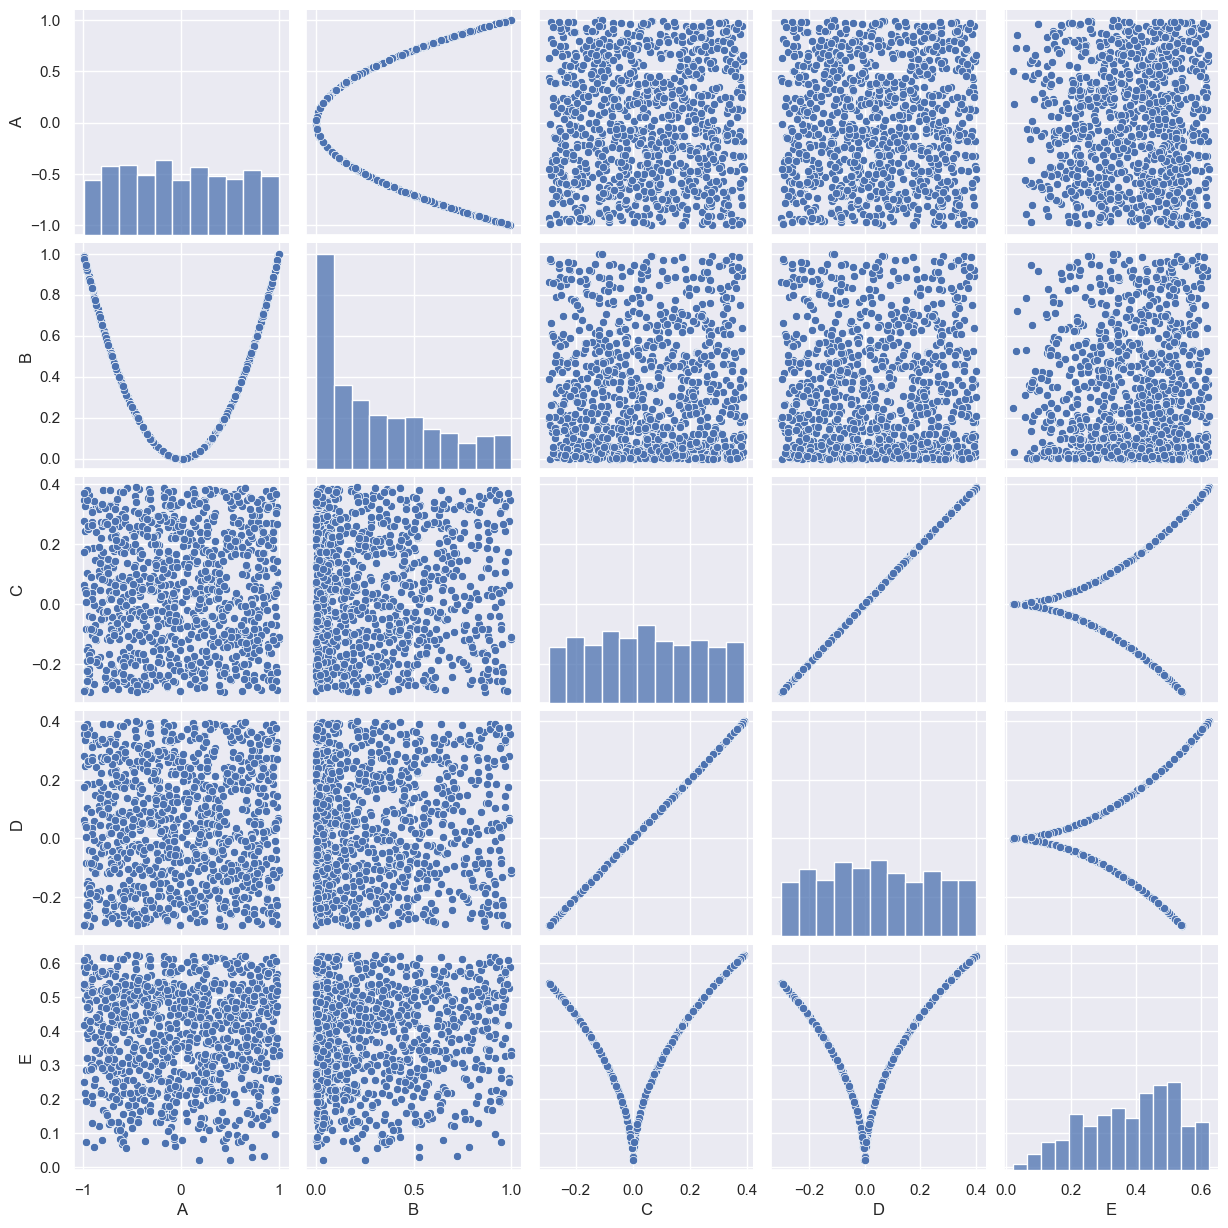

In [32]:
# В переменную many_factors загружена таблица из файла many_factors_data.csv
many_factors = pd.read_csv('many_factors_data.csv')

sns.pairplot(many_factors)

Задание 8

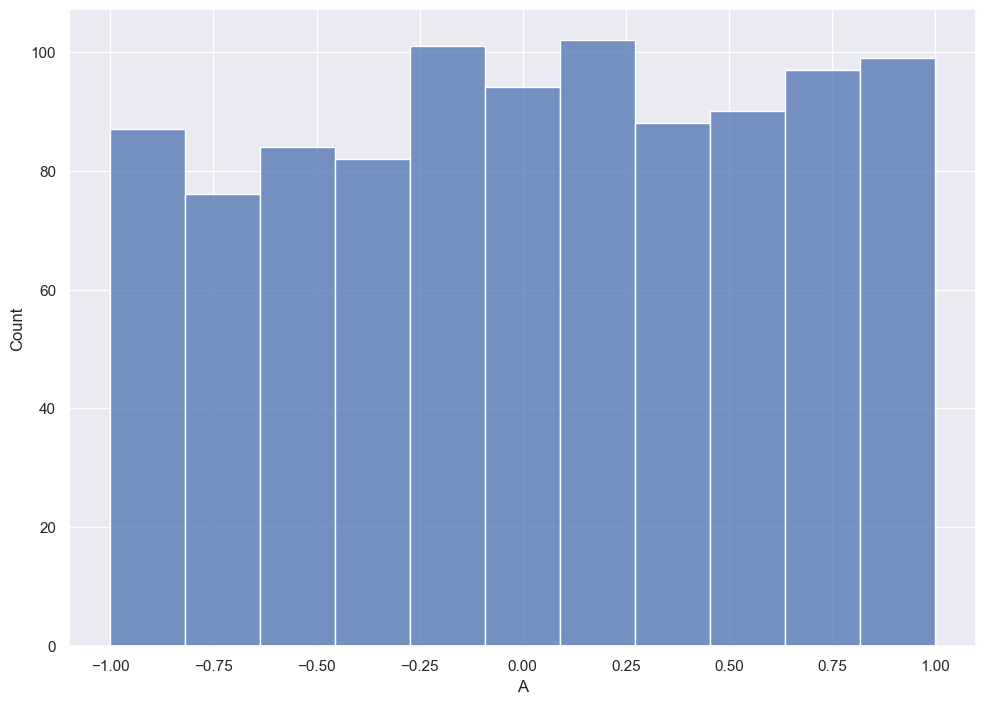

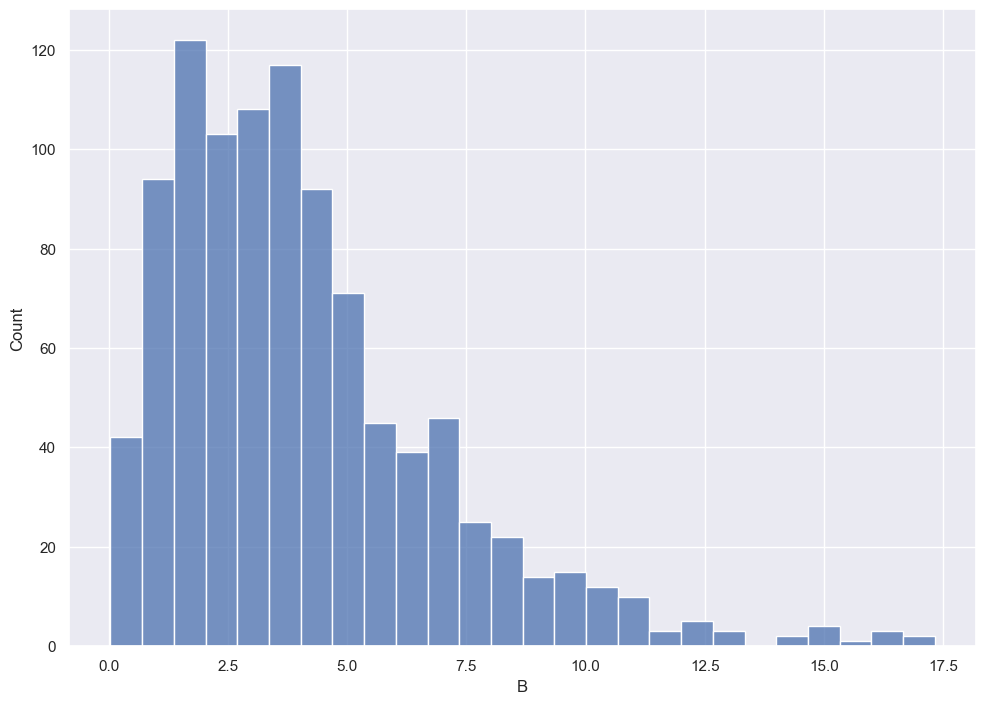

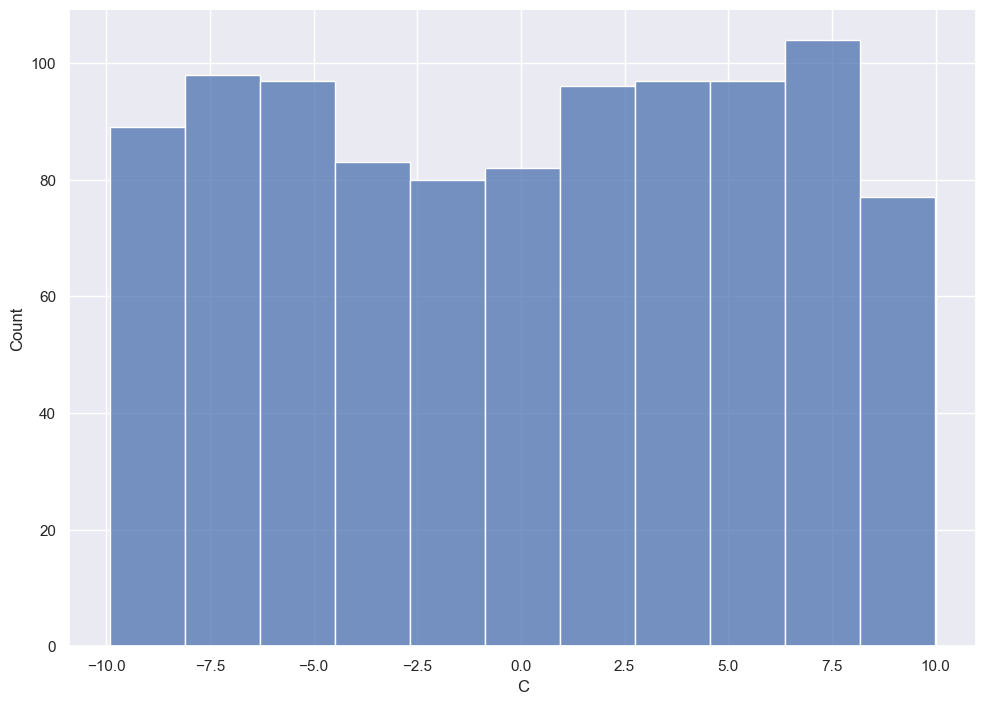

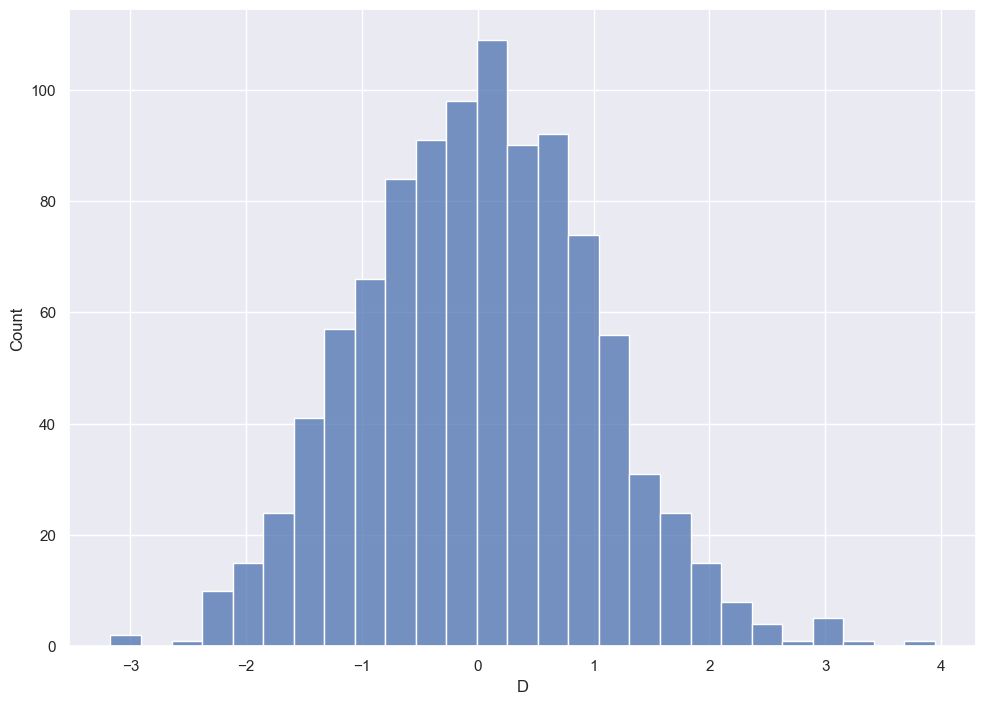

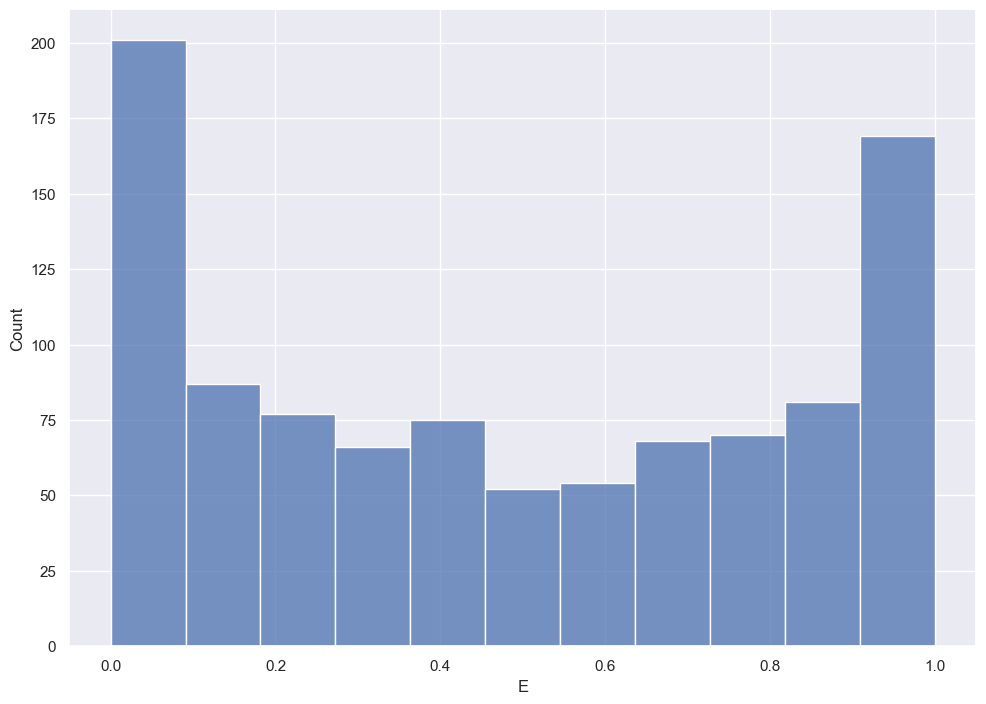

In [31]:
# В переменную uniform_and_not загружена таблица из файла uniform_and_not_data
uniform_and_not = pd.read_csv('uniform_and_not_data.csv')
import matplotlib.pyplot as plt

for col in uniform_and_not.columns:
    sns.histplot(uniform_and_not[col])
    plt.show()